Mann-Whitney U test: U = 102.00, p = 0.0228


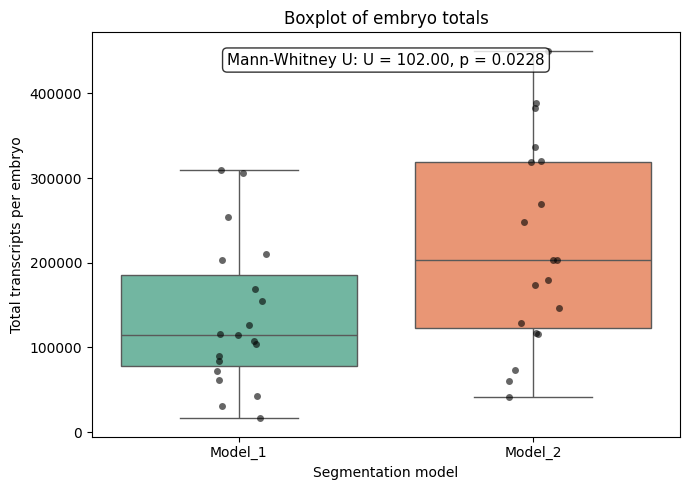

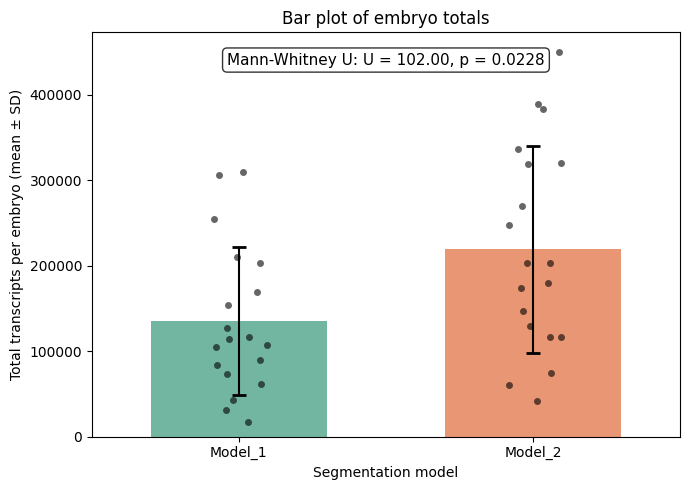

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Load the two CSV files
df_model1 = pd.read_csv('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/FigS4A/Model_1_embryo_totals.csv')
df_model2 = pd.read_csv('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/FigS4A/Model_2_embryo_totals.csv')

# Combine into one DataFrame
combined = pd.concat([df_model1, df_model2], ignore_index=True)

# --- Mann-Whitney U test (unpaired, because embryos are independent between models) ---
model1_totals = df_model1['embryo_total']
model2_totals = df_model2['embryo_total']
u_stat, p_value = mannwhitneyu(model1_totals, model2_totals, alternative='two-sided')
print(f"Mann-Whitney U test: U = {u_stat:.2f}, p = {p_value:.4f}")

# Prepare summary statistics for bar plot (mean and SD across embryos)
summary = combined.groupby('model')['embryo_total'].agg(
    mean='mean',
    sd='std'
).reset_index()

# -------------------------------
# 1. BOXPLOT with individual points
# -------------------------------
plt.figure(figsize=(7, 5))
ax1 = sns.boxplot(data=combined, x='model', y='embryo_total', hue='model',
                  palette='Set2', showfliers=False, legend=False)
sns.stripplot(data=combined, x='model', y='embryo_total',
              color='black', size=5, jitter=True, alpha=0.6, ax=ax1)

ax1.set_ylabel('Total transcripts per embryo')
ax1.set_xlabel('Segmentation model')
ax1.set_title('Boxplot of embryo totals')

# Add statistical annotation
stat_text = f"Mann-Whitney U: U = {u_stat:.2f}, p = {p_value:.4f}"
plt.text(0.5, 0.95, stat_text, transform=ax1.transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# -------------------------------
# 2. BAR PLOT with mean ± SD
# -------------------------------
plt.figure(figsize=(7, 5))
ax2 = sns.barplot(data=summary, x='model', y='mean',
                  palette='Set2', width=0.6, errorbar=None, hue='model', legend=False)

# Add SD error bars
ax2.errorbar(x=range(len(summary)), y=summary['mean'],
             yerr=summary['sd'], fmt='none', color='black',
             capsize=5, capthick=2)

# Overlay individual embryo points (jittered)
sns.stripplot(data=combined, x='model', y='embryo_total',
              color='black', size=5, jitter=True, alpha=0.6, ax=ax2)

ax2.set_ylabel('Total transcripts per embryo (mean ± SD)')
ax2.set_xlabel('Segmentation model')
ax2.set_title('Bar plot of embryo totals')

# Add statistical annotation
plt.text(0.5, 0.95, stat_text, transform=ax2.transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()